--- 1. Dataset Shape ---
Rows: 150, Columns: 5

--- 2. Column Names ---
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'] 

--- 3. First 5 Rows (.head()) ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa 

--- 4. Data Info (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    obje

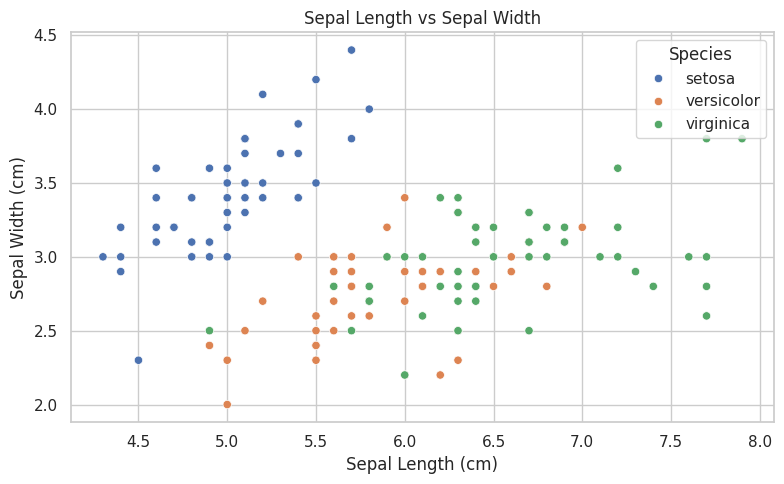

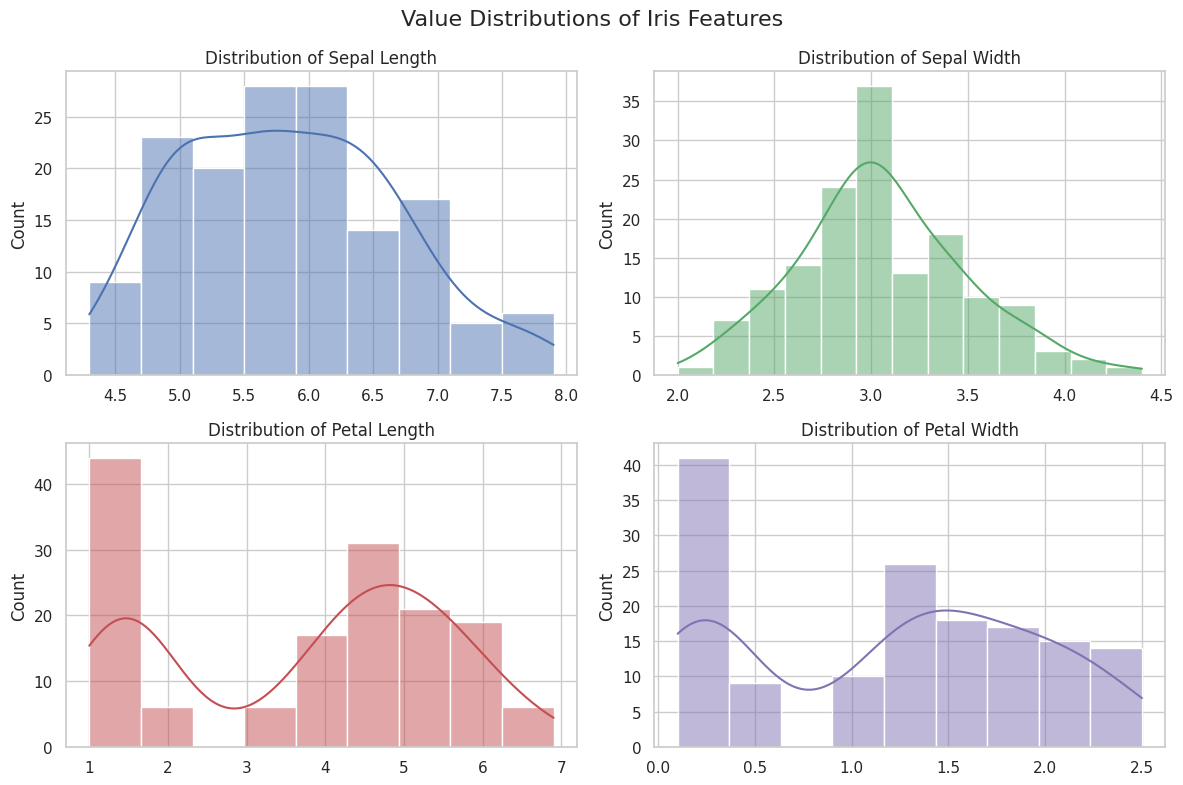

/tmp/ipykernel_1740/2477427267.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Feature", y="Value", palette="Pastel1")


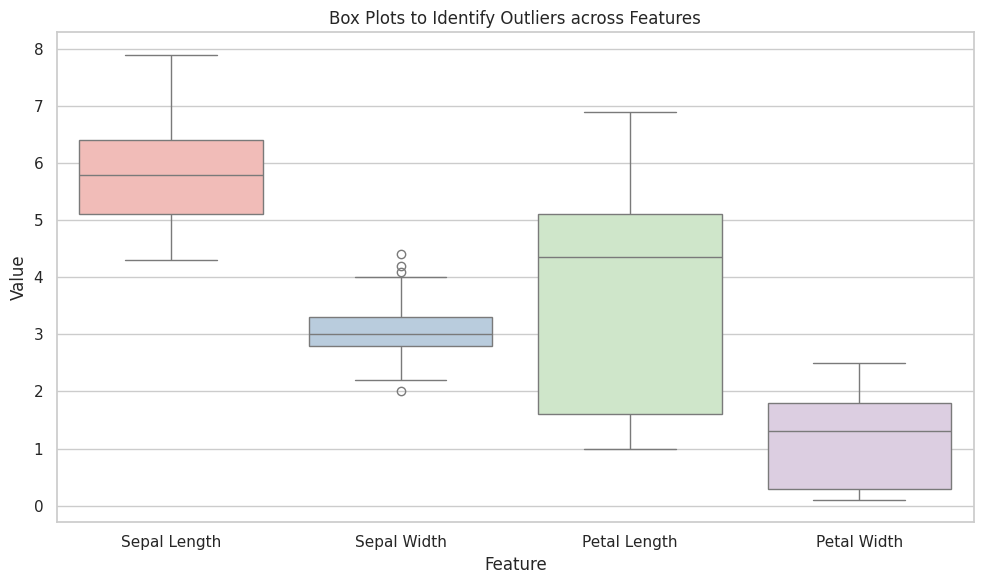

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =====================================================================
# 1. Loading the Dataset
# =====================================================================
# We load the classic Iris dataset directly from seaborn's built-in repository
df = sns.load_dataset("iris")

# =====================================================================
# 2. Inspecting the Data
# =====================================================================
print("--- 1. Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- 2. Column Names ---")
print(list(df.columns), "\n")

print("--- 3. First 5 Rows (.head()) ---")
print(df.head(), "\n")

print("--- 4. Data Info (.info()) ---")
df.info()
print("\n")

print("--- 5. Summary Statistics (.describe()) ---")
print(df.describe(), "\n")

# =====================================================================
# 3. Visualizing the Data
# =====================================================================
# Set a clean visual style for Seaborn
sns.set_theme(style="whitegrid")

# --- Plot 1: Scatter Plot ---
# Showing the relationship between sepal length and sepal width, colored by species
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width", hue="species", palette="deep"
)
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

# --- Plot 2: Histograms (Value Distributions) ---
# Plotting the distribution of each of the 4 numerical features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Value Distributions of Iris Features", fontsize=16)

features = df.columns[:-1]  # Get only the numerical columns
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[i])
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()}")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

# --- Plot 3: Box Plots (Identifying Outliers) ---
# Reshaping the data using melt to easily plot all features side-by-side
plt.figure(figsize=(10, 6))
df_melted = pd.melt(
    df, id_vars="species", value_vars=features, var_name="Feature", value_name="Value"
)
sns.boxplot(data=df_melted, x="Feature", y="Value", palette="Pastel1")
plt.title("Box Plots to Identify Outliers across Features")
plt.xticks(
    ticks=range(4),
    labels=["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"],
)
plt.tight_layout()
plt.show()